<a href="https://colab.research.google.com/github/Keshav820/Housing-Pricing-Models/blob/main/Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the necessary library for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Libraries for Model Selection
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Libraries for Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline, FeatureUnion

# Libraries for Building Models
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importing the dataset
path = "/content/housing.csv"
df = pd.read_csv(path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Dataset Features**

1. Longitude: The longitude of the center of each block group in California.

2. Latitude: The latitude of the center of each block group in California.

3. Housing Median Age: The median age of the housing units in each block group.

4. Total Rooms: The total number of rooms in the housing units in each block group.

5. Total Bedrooms: The total number of bedrooms in the housing units in each block group.

6. Population: The total population of the block group.

7. Households: The total number of households in the block group.

8. Median Income: The median income of the block group.

9. Median House Value: The median value of the housing units in the block group.

10. Ocean Proximity: The proximity of the block group to the ocean or other bodies of water.



# Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
 print(df["ocean_proximity"].unique())

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


## Visualizing Distribution and Correlation

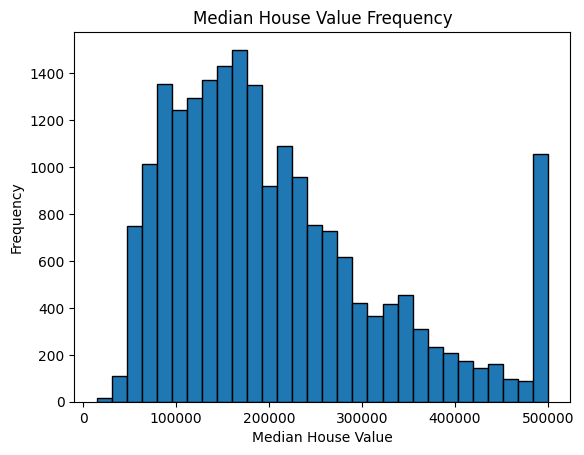

In [ ]:
# Plotting the Histogram - Frequencies Median House Value
plt.hist(df["median_house_value"], bins=30, edgecolor="black")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Median House Value Frequency");

In [ ]:
# plotting the frequency density of the Median House Value
fig = px.histogram(df, x="median_house_value", nbins=30, title="Median House Value Distribution", histnorm="density")
fig.update_traces(marker=dict(color='skyblue', line=dict(color='black', width=0.2)))
fig.show()

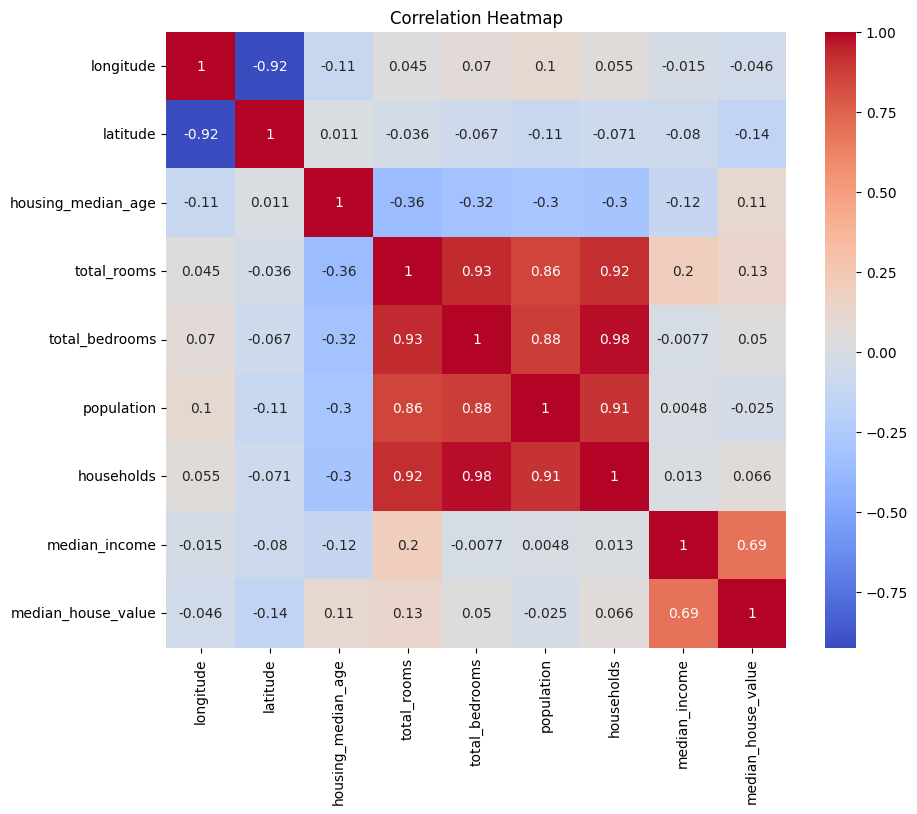

In [ ]:
# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show();

In [ ]:
ocean_proximity_unique = df["ocean_proximity"].unique()
print(ocean_proximity_unique)

# Boxplot of Median House Value by Categorical Variables - Ocean Proximity
qualitative = ["ocean_proximity"]
for c in qualitative:
  df[c] = df[c].astype("category")
  if df[c].isnull().any():
    df[c] = df[c].cat.add_categories(['MISSING'])
    df[c] = df[c].fillna(["MISSING"])

df_melted = df.melt(
    id_vars=["median_house_value"],
    value_vars=qualitative,
    var_name="Variable",
    value_name="Value"
    )
fig = px.box(
    df_melted,
    x="Value",
    y="median_house_value",
    facet_col="Variable",
    title="Boxplot of Median House Value by Categorical Variables",
    color="Value"
    )
fig.update_xaxes(tickangle=90)
fig.update_layout(showlegend=False)
fig.show();

['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Categories (5, object): ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']


In [ ]:
missing_data = df.isnull().sum().reset_index()
missing_data.columns = ['Column', 'Missing Values']
fig = px.bar(missing_data, x='Column', y='Missing Values', title='Missing Values per Column')
fig.show()

In [ ]:
numerical_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
for col in numerical_cols:
    fig = px.histogram(df, x=col, nbins=30, title=f'Distribution of {col}')
    fig.update_traces(marker=dict(color='skyblue', line=dict(color='black', width=0.1)))
    fig.show()

In [ ]:
for col in numerical_cols:
    fig = px.box(df, y=col, title=f'Boxplot of {col}')
    fig.show()

In [ ]:
fig = px.scatter(df, x='median_income', y='median_house_value',
                 color='ocean_proximity', title='Income vs House Value by Ocean Proximity')
fig.show()

# Data Preprocessing

In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

df.corr(numeric_only = True)['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
ocean_proximity_NEAR BAY,0.160284
ocean_proximity_NEAR OCEAN,0.141862
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049457
ocean_proximity_ISLAND,0.023416
population,-0.024650


In [ ]:
X = df.drop(columns=['median_house_value'], axis=1)
y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Standardize the Dataset

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[ 1.27258656, -1.3728112 ,  0.34849025, ..., -0.01556621,
        -0.35564565,  2.62975816],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.01556621,
        -0.35564565,  2.62975816],
       [-0.44760309, -0.46014647, -1.95271028, ..., -0.01556621,
        -0.35564565,  2.62975816],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [-1.18553953,  0.90651045, -1.07984112, ..., -0.01556621,
        -0.35564565, -0.3802631 ],
       [-1.41489815,  0.99543676,  1.85617335, ..., -0.01556621,
         2.81178749, -0.3802631 ]])

# Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print('Accuracy:',model.score(X_train, y_train)*100)

Accuracy: 64.96648627123223


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2*100}")

Mean Squared Error: 4908476721.156616
Mean Absolute Error: 50670.73824097191
R^2 Score: 62.54240620553606


# LASSO Regression

In [ ]:
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
train_accuracy = lasso_model.score(X_train, y_train) * 100
print(f"Training Accuracy: {train_accuracy}")

Training Accuracy: 64.96648541450386


In [ ]:
y_pred = lasso_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2 * 100}")

Mean Squared Error: 4908382747.104245
Mean Absolute Error: 50670.132335685346
R^2 Score: 62.54312334082688


# Decision Tree Regressor

In [ ]:
data = DecisionTreeRegressor(max_depth=8, random_state=42)
data.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [ ]:
print("Accuracy in train", data.score(X_train, y_train) * 100)
print("Accuracy in test:", data.score(X_test, y_test) * 100)

Accuracy in train 75.64770486447969
Accuracy in test: 69.89128831894362


In [ ]:
y_pred = data.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2 * 100}")

Mean Squared Error: 3945472611.0122924
Mean Absolute Error: 42856.370788819455
R^2 Score: 69.89128831894362


# Random Forest Regressor

In [ ]:
regressor = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=0, max_samples=0.8)

In [ ]:
regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_samples=0.8, n_estimators=50,
                      random_state=0)

In [ ]:
print("Accuracy in train:", regressor.score(X_train, y_train)*100)
print("Accuracy in test:", regressor.score(X_test, y_test)*100)

Accuracy in train: 85.53426526421643
Accuracy in test: 78.22843516849349


In [ ]:
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2 * 100}")

Mean Squared Error: 2852965402.555996
Mean Absolute Error: 35958.97215993168
R^2 Score: 78.22843516849349


# Gradient Boosting Regressor

In [ ]:
GBR = GradientBoostingRegressor(n_estimators=100, max_depth=5)

In [ ]:
gbr = GBR.fit(X_train, y_train)

In [ ]:
print("Accuracy in train:", gbr.score(X_train, y_train)*100)
print("Accuracy in test:", gbr.score(X_test, y_test)*100)

Accuracy in train: 86.13120951594796
Accuracy in test: 80.50999199514489


In [ ]:
y_pred = gbr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2 * 100}")

Mean Squared Error: 2553988147.554914
Mean Absolute Error: 34036.8870757444
R^2 Score: 80.50999199514489


# K Neighbours Regressor

In [ ]:
model1 =KNeighborsRegressor(n_neighbors=4)
model1.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=4)

In [ ]:
print("Accuracy in train:", model1.score(X_train, y_train)*100)
print("Accuracy in test:", model1.score(X_test, y_test)*100)

Accuracy in train: 83.27011298475728
Accuracy in test: 70.57043902185107


In [ ]:
y_pred = model1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2*100}")

Mean Squared Error: 3856476093.1454396
Mean Absolute Error: 41260.49745639535
R^2 Score: 70.57043902185107
